# NB07 — Skenario B: FQA Scoring & Kalibrasi Threshold

**Tujuan:**
1. Hitung FQA sub-scores (blur, resolusi, illumination, noise, pose) untuk seluruh 15.248 wajah dari dataset DOKUMENTASI OUTDOOR 2025
2. Validasi statistik: apakah skor FQA wajah noise secara signifikan lebih rendah dari wajah yang berhasil dicluster? (Mann-Whitney U)
3. Kalibrasi threshold θ per sub-score via Youden's J dari ROC curve

**Input:** `output_nb05/metadata_labeled.pkl` + foto asli  
**Output:** `output_nb07/fqa_scores_all.csv`, `skenario_b_results.pkl`, `skenario_b_thresholds.csv`, `roc_curves.png`

**Runtime:** CPU-only (tidak butuh GPU)

In [11]:
# Cell 1 — Install
!pip install -q scipy

In [12]:
# Cell 2 — Imports & Mount
import pickle
import math
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict
from scipy import stats
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')
print('Mount OK')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Mount OK
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Mount OK


In [13]:
# Cell 3 — Config & Konstanta FQA
BASE       = Path("/content/drive/MyDrive/OTW S.KOM/Embeddings")
NB05_DIR   = BASE / "output_nb05"
OUTPUT_DIR = BASE / "output_nb07"
OUTPUT_DIR.mkdir(exist_ok=True)

# Konstanta FQA — identik dengan EXP_Classical_vs_DL_Restoration.ipynb
# Nilai ini TIDAK BOLEH diubah agar hasil reprodusibel dengan Skenario C
VARLAP_REF   = 300.0
NOISE_REF    = 15.0
ILLUM_SIGMA  = 50.0
CONTRAST_REF = 60.0

print('Config OK')
print(f'Output dir: {OUTPUT_DIR}')

Config OK
Output dir: /content/drive/MyDrive/OTW S.KOM/Embeddings/output_nb07
Config OK
Output dir: /content/drive/MyDrive/OTW S.KOM/Embeddings/output_nb07


In [14]:
# Cell 4 — Definisi Fungsi FQA
# Copy-paste PERSIS dari EXP_Classical_vs_DL_Restoration.ipynb (cell-13)
# untuk memastikan reprodusibilitas dengan Skenario C

def immerkaer_sigma(gray):
    """Fast noise variance estimator (Immerkær, 1996)."""
    H, W = gray.shape
    if H < 2 or W < 2:
        return 0.0
    kernel = np.array([[1, -2, 1], [-2, 4, -2], [1, -2, 1]], dtype=np.float64)
    resp = cv2.filter2D(gray.astype(np.float64), -1, kernel)
    return np.sqrt(np.abs(resp).sum() * math.pi / (6 * (H - 2) * (W - 2)) + 1e-9)


def compute_sub_scores(native_bgr, bbox, kps):
    """Hitung 5 sub-skor FQA dari crop wajah native resolution.

    Args:
        native_bgr: np.ndarray BGR crop wajah (native resolution, sebelum resize)
        bbox: [x1, y1, x2, y2] koordinat wajah di foto asli
        kps: array (5, 2) landmark InsightFace, atau None jika tidak tersedia

    Returns:
        dict sub-scores: blur, resolution, illumination, noise, pose,
                         _mean_brightness_raw, _contrast_score, _illum_mean_s
    """
    gray = cv2.cvtColor(native_bgr, cv2.COLOR_BGR2GRAY)

    # --- Blur: Variance of Laplacian (Pech-Pacheco et al., 2000) ---
    var_lap = cv2.Laplacian(gray, cv2.CV_64F).var()
    blur_s  = float(np.clip(var_lap / VARLAP_REF, 0, 1))

    # --- Resolusi: rasio sisi terpendek bbox terhadap 112px ---
    bw    = bbox[2] - bbox[0]
    bh    = bbox[3] - bbox[1]
    res_s = float(np.clip(min(bw, bh) / 112.0, 0, 1))

    # --- Illumination: Gaussian score (mean) + contrast ternormalisasi ---
    mean_b       = float(gray.mean())
    illum_mean_s = float(math.exp(-((mean_b - 128.0) ** 2) / (2 * ILLUM_SIGMA ** 2)))
    contrast_s   = float(np.clip(gray.std() / CONTRAST_REF, 0, 1))

    # --- Noise: Immerkær estimator (σ), dibalik agar tinggi = bersih ---
    sigma   = immerkaer_sigma(gray)
    noise_s = float(np.clip(1.0 - sigma / NOISE_REF, 0, 1))

    # --- Pose: yaw ratio dari 5-point landmark InsightFace ---
    if kps is not None:
        le, re, nose = kps[0], kps[1], kps[2]
        d_l = abs(nose[0] - le[0])
        d_r = abs(re[0] - nose[0])
        yaw = min(d_l, d_r) / max(d_l, d_r) if max(d_l, d_r) > 0 else 0.0
    else:
        yaw = None  # pose tidak dihitung jika kps tidak tersedia

    return {
        "blur":        blur_s,
        "resolution":  res_s,
        "illumination": 0.5 * illum_mean_s + 0.5 * contrast_s,
        "noise":       noise_s,
        "pose":        yaw,
        "_mean_brightness_raw": mean_b,
        "_contrast_score":      contrast_s,
        "_illum_mean_s":        illum_mean_s,
    }


print('Fungsi FQA terdefinisi: immerkaer_sigma, compute_sub_scores')

Fungsi FQA terdefinisi: immerkaer_sigma, compute_sub_scores
Fungsi FQA terdefinisi: immerkaer_sigma, compute_sub_scores


In [15]:
# Cell 5 — Load Metadata
with open(NB05_DIR / "metadata_labeled.pkl", "rb") as f:
    meta = pickle.load(f)

labels = np.array([m["cluster_id"] for m in meta])

print(f"Total wajah  : {len(meta)}")
print(f"Noise        : {(labels == -1).sum()} ({(labels == -1).mean()*100:.1f}%)")
print(f"Clustered    : {(labels >= 0).sum()} ({(labels >= 0).mean()*100:.1f}%)")
print(f"\nCek kps di metadata: {list(meta[0].keys())}")
has_kps = "kps" in meta[0]
print(f"kps tersedia : {'YA' if has_kps else 'TIDAK — pose score akan dilewati'}")

Total wajah  : 15248
Noise        : 3871 (25.4%)
Clustered    : 11377 (74.6%)

Cek kps di metadata: ['photo_path', 'photo_name', 'face_idx', 'bbox', 'det_score', 'cluster_id', 'is_noise']
kps tersedia : TIDAK — pose score akan dilewati
Total wajah  : 15248
Noise        : 3871 (25.4%)
Clustered    : 11377 (74.6%)

Cek kps di metadata: ['photo_path', 'photo_name', 'face_idx', 'bbox', 'det_score', 'cluster_id', 'is_noise']
kps tersedia : TIDAK — pose score akan dilewati


In [16]:
# Cell 6 — Hitung FQA Semua Wajah (dengan photo caching)
# Baca setiap foto 1× saja, crop semua wajah dari foto tersebut
# Kompleksitas: O(n_photos × H × W) — CPU-only, ~20-60 detik

# Kelompokkan global index berdasarkan photo_path
photo_to_indices = defaultdict(list)
for gi, m in enumerate(meta):
    photo_to_indices[m["photo_path"]].append(gi)

print(f"Jumlah foto unik: {len(photo_to_indices)}")
print("Memulai komputasi FQA...")

_NAN_RECORD = {
    k: float("nan") for k in
    ["blur", "resolution", "illumination", "noise", "pose",
     "_mean_brightness_raw", "_contrast_score", "_illum_mean_s"]
}

scores_list = [None] * len(meta)
n_failed = 0

for idx_photo, (photo_path, indices) in enumerate(photo_to_indices.items()):
    if idx_photo % 50 == 0:
        print(f"  [{idx_photo}/{len(photo_to_indices)}] foto diproses...", end="\r")

    img = cv2.imread(str(photo_path))
    if img is None:
        n_failed += len(indices)
        for gi in indices:
            scores_list[gi] = dict(_NAN_RECORD)
        continue

    for gi in indices:
        m  = meta[gi]
        x1, y1, x2, y2 = [int(v) for v in m["bbox"]]
        crop = img[max(0, y1):y2, max(0, x1):x2]
        if crop.size == 0:
            n_failed += 1
            scores_list[gi] = dict(_NAN_RECORD)
            continue
        kps = m.get("kps", None)
        scores_list[gi] = compute_sub_scores(crop, m["bbox"], kps)

print(f"\nSelesai. Gagal/NaN: {n_failed} wajah")

df_scores = pd.DataFrame(scores_list)
df_scores["cluster_id"] = labels
df_scores["is_noise"]   = (labels == -1).astype(int)

df_scores.to_csv(OUTPUT_DIR / "fqa_scores_all.csv", index=False)
print(f"Tersimpan: output_nb07/fqa_scores_all.csv ({len(df_scores)} baris)")
print("\nStatistik deskriptif:")
display(df_scores[["blur", "resolution", "illumination", "noise", "pose", "is_noise"]].describe().round(4))

Jumlah foto unik: 2435
Memulai komputasi FQA...

Selesai. Gagal/NaN: 1234 wajah
Tersimpan: output_nb07/fqa_scores_all.csv (15248 baris)

Statistik deskriptif:


,blur,resolution,illumination,noise,pose,is_noise
count,14014.0000,14014.0000,14014.0000,14014.0000,0.0,15248.0000
mean,0.1298,0.9482,0.5826,0.9229,NaN,0.2539
std,0.1677,0.1226,0.2144,0.0177,NaN,0.4352
min,0.0055,0.3366,0.0440,0.7147,NaN,0.0000
25%,0.0292,1.0000,0.4209,0.9159,NaN,0.0000
50%,0.0518,1.0000,0.6058,0.9314,NaN,0.0000
75%,0.1638,1.0000,0.7547,0.9342,NaN,1.0000
max,1.0000,1.0000,1.0000,0.9591,NaN,1.0000


Jumlah foto unik: 2435
Memulai komputasi FQA...

Selesai. Gagal/NaN: 1234 wajah
Tersimpan: output_nb07/fqa_scores_all.csv (15248 baris)

Statistik deskriptif:


,blur,resolution,illumination,noise,pose,is_noise
count,14014.0000,14014.0000,14014.0000,14014.0000,0.0,15248.0000
mean,0.1298,0.9482,0.5826,0.9229,NaN,0.2539
std,0.1677,0.1226,0.2144,0.0177,NaN,0.4352
min,0.0055,0.3366,0.0440,0.7147,NaN,0.0000
25%,0.0292,1.0000,0.4209,0.9159,NaN,0.0000
50%,0.0518,1.0000,0.6058,0.9314,NaN,0.0000
75%,0.1638,1.0000,0.7547,0.9342,NaN,1.0000
max,1.0000,1.0000,1.0000,0.9591,NaN,1.0000


In [17]:
# Cell 7 — Mann-Whitney U Test
# Hipotesis terarah (alternative='less'): wajah noise memiliki skor FQA
# LEBIH RENDAH dari wajah yang berhasil dicluster
# Effect size: rank-biserial r = 1 - 2U/(n1*n2)
# Interpretasi r: <0.1 kecil, 0.1-0.3 sedang, >0.3 besar (Cohen, 1988)

noise_mask     = df_scores["is_noise"] == 1
clustered_mask = df_scores["is_noise"] == 0

# Tentukan sub-scores yang akan dianalisis
sub_scores = ["blur", "resolution", "illumination", "noise"]
if df_scores["pose"].notna().any():
    sub_scores.append("pose")
    print("✓ kps tersedia — pose score diikutsertakan")
else:
    print("✗ kps tidak ada di metadata — pose score dilewati")

print(f"\nn_noise     = {noise_mask.sum()}")
print(f"n_clustered = {clustered_mask.sum()}")
print()

mw_results = {}
print(f"{'Sub-score':15s}  {'mean_noise':10s}  {'mean_clustered':14s}  {'U':>10s}  {'p-value':>12s}  {'r':>6s}  Sig?")
print("-" * 80)

for sc in sub_scores:
    a = df_scores.loc[noise_mask,     sc].dropna().values
    b = df_scores.loc[clustered_mask, sc].dropna().values
    stat, p = stats.mannwhitneyu(a, b, alternative='less')
    r = 1.0 - (2.0 * stat) / (len(a) * len(b))  # rank-biserial effect size
    mw_results[sc] = {
        "n_noise":     int(len(a)),
        "n_clustered": int(len(b)),
        "mean_noise":     float(a.mean()),
        "mean_clustered": float(b.mean()),
        "U":          float(stat),
        "p_value":    float(p),
        "effect_r":   float(r),
        "significant": bool(p < 0.05),
    }
    sig_mark = "✓" if p < 0.05 else "✗"
    print(f"{sc:15s}  {a.mean():10.4f}  {b.mean():14.4f}  {stat:>10.0f}  {p:>12.4e}  {r:>6.3f}  {sig_mark}")

✗ kps tidak ada di metadata — pose score dilewati

n_noise     = 3871
n_clustered = 11377

Sub-score        mean_noise  mean_clustered           U       p-value       r  Sig?
--------------------------------------------------------------------------------
blur                 0.1351          0.1280    18734639    5.5134e-01  -0.001  ✗
resolution           0.9206          0.9577    16337066    2.8719e-57   0.127  ✓
illumination         0.5429          0.5963    16121389    1.8499e-35   0.138  ✓
noise                0.9219          0.9233    17968640    2.0365e-04   0.040  ✓
✗ kps tidak ada di metadata — pose score dilewati

n_noise     = 3871
n_clustered = 11377

Sub-score        mean_noise  mean_clustered           U       p-value       r  Sig?
--------------------------------------------------------------------------------
blur                 0.1351          0.1280    18734639    5.5134e-01  -0.001  ✗
resolution           0.9206          0.9577    16337066    2.8719e-57   0.127  ✓
il

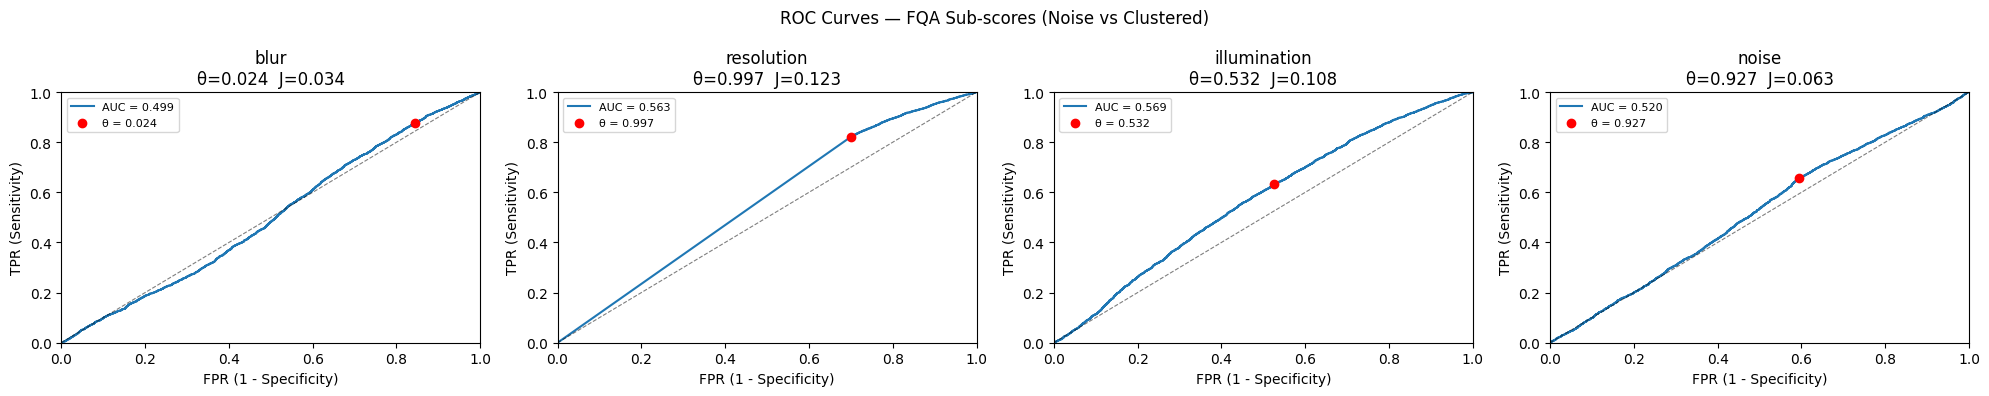

Tersimpan: output_nb07/roc_curves.png

Rekomendasi threshold θ (Youden's J):
Sub-score              θ    Sens    Spec       J     AUC
------------------------------------------------------------
blur               0.024   0.877   0.157   0.034   0.499
resolution         0.997   0.822   0.300   0.123   0.563
illumination       0.532   0.634   0.474   0.108   0.569
noise              0.927   0.657   0.407   0.063   0.520


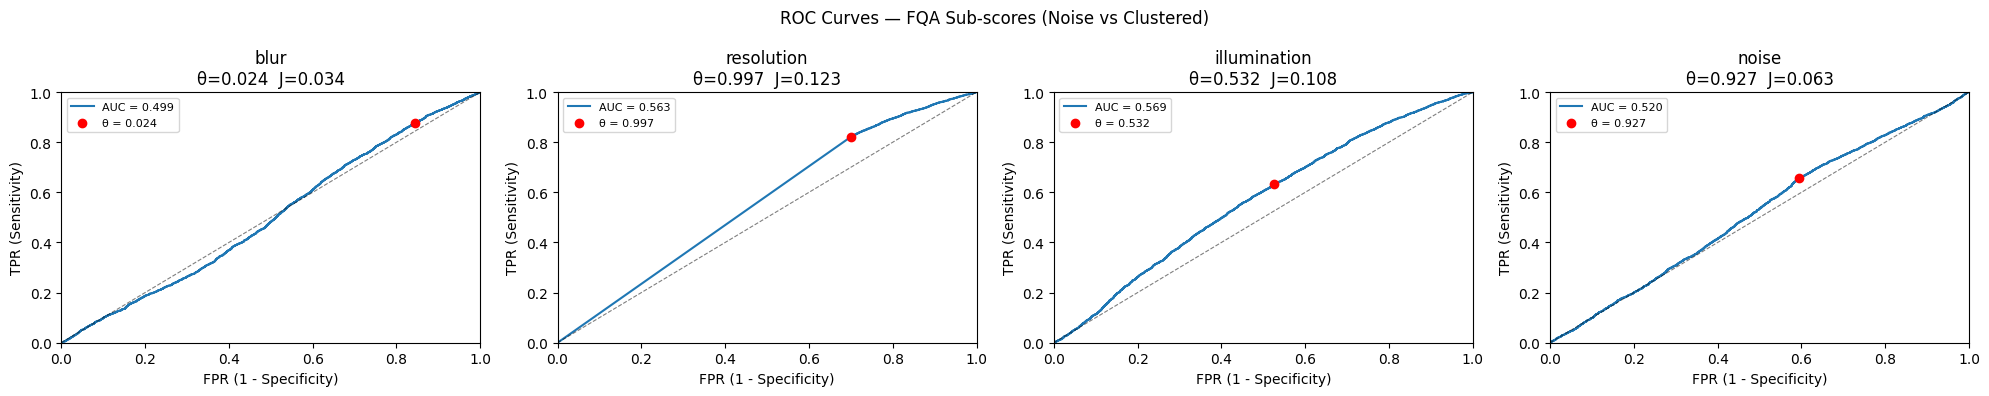

Tersimpan: output_nb07/roc_curves.png

Rekomendasi threshold θ (Youden's J):
Sub-score              θ    Sens    Spec       J     AUC
------------------------------------------------------------
blur               0.024   0.877   0.157   0.034   0.499
resolution         0.997   0.822   0.300   0.123   0.563
illumination       0.532   0.634   0.474   0.108   0.569
noise              0.927   0.657   0.407   0.063   0.520


In [18]:
# Cell 8 — ROC Curve + Youden's J (Kalibrasi Threshold θ)
# Label biner: clustered = positif (kualitas cukup), noise = negatif
# y_true_roc = 1 jika clustered, 0 jika noise
# Threshold optimal = argmax(Youden's J) = argmax(TPR - FPR)

thresholds_recommended = {}
n_sc = len(sub_scores)
fig, axes = plt.subplots(1, n_sc, figsize=(5 * n_sc, 4))
if n_sc == 1:
    axes = [axes]

for i, sc in enumerate(sub_scores):
    valid      = df_scores[[sc, "is_noise"]].dropna()
    y_true_roc = (1 - valid["is_noise"]).values   # 1 = clustered (positif)
    y_score    = valid[sc].values

    fpr, tpr, thresh = roc_curve(y_true_roc, y_score)
    roc_auc = auc(fpr, tpr)

    J        = tpr - fpr
    best_idx = int(np.argmax(J))
    best_t   = float(thresh[best_idx])

    thresholds_recommended[sc] = {
        "theta":       best_t,
        "sensitivity": float(tpr[best_idx]),
        "specificity": float(1.0 - fpr[best_idx]),
        "youden_J":    float(J[best_idx]),
        "auc_roc":     float(roc_auc),
    }

    ax = axes[i]
    ax.plot(fpr, tpr, lw=1.5, label=f"AUC = {roc_auc:.3f}")
    ax.scatter(fpr[best_idx], tpr[best_idx], color='red', zorder=5,
               label=f"θ = {best_t:.3f}")
    ax.plot([0, 1], [0, 1], 'k--', lw=0.8, alpha=0.5)
    ax.set_title(f"{sc}\nθ={best_t:.3f}  J={J[best_idx]:.3f}")
    ax.set_xlabel("FPR (1 - Specificity)")
    ax.set_ylabel("TPR (Sensitivity)")
    ax.legend(fontsize=8)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])

plt.suptitle("ROC Curves — FQA Sub-scores (Noise vs Clustered)", fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "roc_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Tersimpan: output_nb07/roc_curves.png")

print("\nRekomendasi threshold θ (Youden's J):")
print(f"{'Sub-score':15s}  {'θ':>7s}  {'Sens':>6s}  {'Spec':>6s}  {'J':>6s}  {'AUC':>6s}")
print("-" * 60)
for sc, v in thresholds_recommended.items():
    print(f"{sc:15s}  {v['theta']:7.3f}  {v['sensitivity']:6.3f}  "
          f"{v['specificity']:6.3f}  {v['youden_J']:6.3f}  {v['auc_roc']:6.3f}")

In [19]:
# Cell 9 — Ringkasan Tabel

rows = []
for sc in sub_scores:
    rows.append({
        "sub_score":      sc,
        "mean_noise":     round(mw_results[sc]["mean_noise"], 4),
        "mean_clustered": round(mw_results[sc]["mean_clustered"], 4),
        "delta_mean":     round(mw_results[sc]["mean_clustered"] - mw_results[sc]["mean_noise"], 4),
        "p_value":        mw_results[sc]["p_value"],
        "effect_r":       round(mw_results[sc]["effect_r"], 3),
        "significant":    mw_results[sc]["significant"],
        "theta_youden":   round(thresholds_recommended[sc]["theta"], 3),
        "sensitivity":    round(thresholds_recommended[sc]["sensitivity"], 3),
        "specificity":    round(thresholds_recommended[sc]["specificity"], 3),
        "youden_J":       round(thresholds_recommended[sc]["youden_J"], 3),
        "auc_roc":        round(thresholds_recommended[sc]["auc_roc"], 3),
    })

df_summary = pd.DataFrame(rows)
print("=" * 80)
print("RINGKASAN SKENARIO B — FQA KALIBRASI THRESHOLD")
print("=" * 80)
display(df_summary)

print("\nCatatan interpretasi:")
print("  delta_mean   = mean_clustered - mean_noise (positif = noise lebih buruk, sesuai hipotesis)")
print("  effect_r     = rank-biserial: |r|<0.1 kecil, 0.1-0.3 sedang, >0.3 besar (Cohen, 1988)")
print("  theta_youden = threshold optimal per sub-score untuk Skenario C")

RINGKASAN SKENARIO B — FQA KALIBRASI THRESHOLD


,sub_score,mean_noise,mean_clustered,delta_mean,p_value,effect_r,significant,theta_youden,sensitivity,specificity,youden_J,auc_roc
0,blur,0.1351,0.1280,-0.0071,5.513415e-01,-0.001,False,0.024,0.877,0.157,0.034,0.499
1,resolution,0.9206,0.9577,0.0370,2.871928e-57,0.127,True,0.997,0.822,0.300,0.123,0.563
2,illumination,0.5429,0.5963,0.0534,1.849927e-35,0.138,True,0.532,0.634,0.474,0.108,0.569
3,noise,0.9219,0.9233,0.0014,2.036518e-04,0.040,True,0.927,0.657,0.407,0.063,0.520



Catatan interpretasi:
  delta_mean   = mean_clustered - mean_noise (positif = noise lebih buruk, sesuai hipotesis)
  effect_r     = rank-biserial: |r|<0.1 kecil, 0.1-0.3 sedang, >0.3 besar (Cohen, 1988)
  theta_youden = threshold optimal per sub-score untuk Skenario C
RINGKASAN SKENARIO B — FQA KALIBRASI THRESHOLD


,sub_score,mean_noise,mean_clustered,delta_mean,p_value,effect_r,significant,theta_youden,sensitivity,specificity,youden_J,auc_roc
0,blur,0.1351,0.1280,-0.0071,5.513415e-01,-0.001,False,0.024,0.877,0.157,0.034,0.499
1,resolution,0.9206,0.9577,0.0370,2.871928e-57,0.127,True,0.997,0.822,0.300,0.123,0.563
2,illumination,0.5429,0.5963,0.0534,1.849927e-35,0.138,True,0.532,0.634,0.474,0.108,0.569
3,noise,0.9219,0.9233,0.0014,2.036518e-04,0.040,True,0.927,0.657,0.407,0.063,0.520



Catatan interpretasi:
  delta_mean   = mean_clustered - mean_noise (positif = noise lebih buruk, sesuai hipotesis)
  effect_r     = rank-biserial: |r|<0.1 kecil, 0.1-0.3 sedang, >0.3 besar (Cohen, 1988)
  theta_youden = threshold optimal per sub-score untuk Skenario C


In [20]:
# Cell 10 — Simpan Output

skenario_b = {
    "skenario":    "B",
    "deskripsi":   "FQA scoring tanpa enhancement — validasi Mann-Whitney U + kalibrasi threshold Youden J",
    "n_total":     int(len(meta)),
    "n_noise":     int(noise_mask.sum()),
    "n_clustered": int(clustered_mask.sum()),
    "sub_scores_analyzed": sub_scores,
    "mann_whitney":  mw_results,
    "thresholds":    thresholds_recommended,
    "fqa_constants": {
        "VARLAP_REF":   VARLAP_REF,
        "NOISE_REF":    NOISE_REF,
        "ILLUM_SIGMA":  ILLUM_SIGMA,
        "CONTRAST_REF": CONTRAST_REF,
    },
}

with open(OUTPUT_DIR / "skenario_b_results.pkl", "wb") as f:
    pickle.dump(skenario_b, f)

df_summary.to_csv(OUTPUT_DIR / "skenario_b_thresholds.csv", index=False)

print("Output tersimpan di:", OUTPUT_DIR)
print("  ✓ fqa_scores_all.csv        (15k baris skor per wajah)")
print("  ✓ skenario_b_results.pkl    (dict lengkap Mann-Whitney + threshold)")
print("  ✓ skenario_b_thresholds.csv (tabel ringkasan per sub-score)")
print("  ✓ roc_curves.png            (grafik ROC)")
print()
print("Threshold untuk Skenario C (salin ke CLAUDE.md):")
for sc, v in thresholds_recommended.items():
    print(f"  {sc:15s} θ = {v['theta']:.3f}")

Output tersimpan di: /content/drive/MyDrive/OTW S.KOM/Embeddings/output_nb07
  ✓ fqa_scores_all.csv        (15k baris skor per wajah)
  ✓ skenario_b_results.pkl    (dict lengkap Mann-Whitney + threshold)
  ✓ skenario_b_thresholds.csv (tabel ringkasan per sub-score)
  ✓ roc_curves.png            (grafik ROC)

Threshold untuk Skenario C (salin ke CLAUDE.md):
  blur            θ = 0.024
  resolution      θ = 0.997
  illumination    θ = 0.532
  noise           θ = 0.927
Output tersimpan di: /content/drive/MyDrive/OTW S.KOM/Embeddings/output_nb07
  ✓ fqa_scores_all.csv        (15k baris skor per wajah)
  ✓ skenario_b_results.pkl    (dict lengkap Mann-Whitney + threshold)
  ✓ skenario_b_thresholds.csv (tabel ringkasan per sub-score)
  ✓ roc_curves.png            (grafik ROC)

Threshold untuk Skenario C (salin ke CLAUDE.md):
  blur            θ = 0.024
  resolution      θ = 0.997
  illumination    θ = 0.532
  noise           θ = 0.927
